<a href="https://colab.research.google.com/github/NanditaPatil-dotcom/PhysSAE/blob/main/PhysSAE_Pareto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Setup

In [2]:
import os, time, math
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib as mpl
from sklearn.decomposition import PCA

# reproducibility
torch.manual_seed(0); np.random.seed(0)
torch.set_num_threads(4)

# publication style
mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 220,
    "font.family": "serif", "font.serif": ["DejaVu Serif"],
    "mathtext.fontset": "cm",
    "axes.titlesize": 11, "axes.labelsize": 10,
    "xtick.labelsize": 9, "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "axes.spines.top": False, "axes.spines.right": False,
})

os.makedirs("artifacts", exist_ok=True)
os.makedirs("figures", exist_ok=True)

# hyperparams
HIDDEN = 40        # PINN hidden width
N_LAYERS = 4       # number of hidden linear layers
DICT = 128         # SAE dictionary size (overcomplete 3.2x)
SAE_EPOCHS = 500
PINN_ITERS = 4000


# PINN Architecture

In [3]:
class PINN(nn.Module):
    def __init__(self, out_dim=1, layers=None):
        super().__init__()

        layers = layers or ([2] +[HIDDEN]*N_LAYERS +[out_dim])

        self.net = nn.ModuleList(
            [nn.Linear(layers[i], layers[i+1])
             for i in range(len(layers)-1)]
        )

        self.act = nn.Tanh()

        for m in self.net:
            nn.init.xavier_normal_(m.weight)
            nn.init.zeros_(m.bias)

        self._hidden = None

    def forward(self,x,t):
        h = torch.cat([x,t],dim=1)

        for layer in self.net[:-1]:
            h = self.act(layer(h))

        self._hidden = h

        return self.net[-1](h)


# Train PINNs

In [4]:
def train_pinn(loss_fn, n_iter=PINN_ITERS, log_every=400, tag="pinn",out_dim=1):
    model = PINN(out_dim=out_dim)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    hist = []; t0 = time.time()
    for it in range(n_iter):
        opt.zero_grad()
        loss, parts = loss_fn(model)
        loss.backward(); opt.step()
        hist.append(parts)
        if it % log_every == 0:
            print(f"[{tag}] it {it:5d} | bc {parts[0]:.2e} ic {parts[1]:.2e} f {parts[2]:.2e} | {time.time()-t0:.0f}s")
    print(f"[{tag}] total {time.time()-t0:.0f}s")
    return model, np.array(hist)

# Train on PDE

In [5]:
nu = 0.01/np.pi
def burgers_loss(model):
    n_b, n_i, n_f = 100, 100, 2500
    x_b1 = -torch.ones(n_b,1); x_b2 = torch.ones(n_b,1); t_b = torch.rand(n_b,1)
    x_i = torch.rand(n_i,1)*2-1; t_i = torch.zeros(n_i,1); u_i = -torch.sin(np.pi*x_i)
    x_f = torch.rand(n_f,1)*2-1; t_f = torch.rand(n_f,1)
    u_b1, u_b2, u_ip = model(x_b1, t_b), model(x_b2, t_b), model(x_i, t_i)
    xfg, tfg = x_f.clone().requires_grad_(True), t_f.clone().requires_grad_(True)
    u = model(xfg, tfg)
    u_t = torch.autograd.grad(u, tfg, torch.ones_like(u), create_graph=True)[0]
    u_x = torch.autograd.grad(u, xfg, torch.ones_like(u), create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, xfg, torch.ones_like(u_x), create_graph=True)[0]
    r = u_t + u*u_x - nu*u_xx
    l_bc = (u_b1**2).mean() + (u_b2**2).mean()
    l_ic = ((u_ip - u_i)**2).mean()
    l_f  = (r**2).mean()
    return 100*l_bc + 100*l_ic + l_f, (l_bc.item(), l_ic.item(), l_f.item())

if os.path.exists("artifacts/burgers_pinn.pt"):
    pinn_b = PINN(out_dim=1); pinn_b.load_state_dict(torch.load("artifacts/burgers_pinn.pt"))
    hist_b = np.load("artifacts/burgers_hist.npy")
    print("Loaded cached Burgers PINN.")
else:
    pinn_b, hist_b = train_pinn(burgers_loss, tag="burgers")
    torch.save(pinn_b.state_dict(), "artifacts/burgers_pinn.pt")
    np.save("artifacts/burgers_hist.npy", hist_b)


[burgers] it     0 | bc 1.10e-02 ic 5.70e-01 f 1.29e-02 | 0s
[burgers] it   400 | bc 1.10e-03 ic 8.67e-03 f 7.04e-01 | 40s
[burgers] it   800 | bc 4.77e-04 ic 7.83e-04 f 4.56e-01 | 77s
[burgers] it  1200 | bc 3.47e-04 ic 3.61e-04 f 4.19e-01 | 115s
[burgers] it  1600 | bc 1.82e-04 ic 1.95e-04 f 4.21e-01 | 152s
[burgers] it  2000 | bc 1.11e-04 ic 2.32e-04 f 4.05e-01 | 189s
[burgers] it  2400 | bc 2.06e-04 ic 1.84e-04 f 4.13e-01 | 226s
[burgers] it  2800 | bc 4.33e-05 ic 1.25e-04 f 3.53e-01 | 263s
[burgers] it  3200 | bc 1.80e-04 ic 2.56e-04 f 3.65e-01 | 299s
[burgers] it  3600 | bc 1.67e-03 ic 4.62e-04 f 3.67e-01 | 336s
[burgers] total 379s


In [41]:
def heat_loss(model):
    n_b, n_i, n_f = 100, 100, 2500
    x_b1 = -torch.ones(n_b,1)
    x_b2 =  torch.ones(n_b,1)
    t_b = torch.rand(n_b,1)
    u_b1 = model(x_b1, t_b)
    u_b2 = model(x_b2, t_b)
    x_i = 2*torch.rand(n_i,1) - 1
    t_i = torch.zeros(n_i,1)
    u_i_true = torch.exp(-5*x_i**2)
    u_i = model(x_i, t_i)
    x_f = 2*torch.rand(n_f,1) - 1
    t_f = torch.rand(n_f,1)
    xfg = x_f.clone().requires_grad_(True)
    tfg = t_f.clone().requires_grad_(True)
    u = model(xfg, tfg)
    u_t = torch.autograd.grad(u,tfg,torch.ones_like(u),create_graph=True)[0]
    u_x = torch.autograd.grad(u,xfg,torch.ones_like(u),create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x,xfg,torch.ones_like(u_x),create_graph=True)[0]

    r = u_t - u_xx

    l_bc = (u_b1**2).mean() + (u_b2**2).mean()
    l_ic = ((u_i - u_i_true)**2).mean()
    l_f = (r**2).mean()
    total = 100*l_bc + 100*l_ic + l_f
    return total, (l_bc.item(),l_ic.item(),l_f.item())

if os.path.exists("artifacts/heat_pinn.pt"):
    pinn_h = PINN(out_dim=1)
    pinn_h.load_state_dict(torch.load("artifacts/heat_pinn.pt"))
    hist_h = np.load("artifacts/heat_hist.npy")
    print("Loaded cached Heat PINN.")
else:
    pinn_h, hist_h = train_pinn(heat_loss,tag="heat")
    torch.save(pinn_h.state_dict(),"artifacts/heat_pinn.pt")
    np.save("artifacts/heat_hist.npy",hist_h)

[heat] it     0 | bc 1.42e-03 ic 2.69e-01 f 4.45e-03 | 0s
[heat] it   400 | bc 5.52e-04 ic 8.56e-04 f 2.99e-01 | 44s
[heat] it   800 | bc 1.61e-04 ic 3.79e-04 f 7.10e-02 | 90s
[heat] it  1200 | bc 1.04e-04 ic 2.06e-04 f 4.10e-02 | 135s
[heat] it  1600 | bc 6.62e-05 ic 1.30e-04 f 2.71e-02 | 180s
[heat] it  2000 | bc 1.46e-04 ic 6.16e-05 f 1.69e-02 | 224s
[heat] it  2400 | bc 1.46e-04 ic 8.40e-05 f 1.85e-02 | 278s
[heat] it  2800 | bc 1.99e-05 ic 2.75e-05 f 1.29e-02 | 323s
[heat] it  3200 | bc 5.05e-05 ic 1.95e-05 f 9.32e-03 | 368s
[heat] it  3600 | bc 4.04e-06 ic 2.42e-05 f 8.30e-03 | 415s
[heat] total 463s


In [42]:
def schrodinger_loss(model):

    n_b, n_i, n_f = 100, 100, 2500
    x_b1 = -5*torch.ones(n_b,1)
    x_b2 =  5*torch.ones(n_b,1)
    t_b  = torch.rand(n_b,1)
    uv_b1 = model(x_b1,t_b)
    uv_b2 = model(x_b2,t_b)
    u_b1 = uv_b1[:,0:1]
    v_b1 = uv_b1[:,1:2]
    u_b2 = uv_b2[:,0:1]
    v_b2 = uv_b2[:,1:2]
    x_i = -5 + 10*torch.rand(n_i,1)
    t_i = torch.zeros(n_i,1)

    uv_i = model(x_i,t_i)

    u_i = uv_i[:,0:1]
    v_i = uv_i[:,1:2]

    eta = 2.0
    v0  = 2.0

    amp0 = eta / torch.cosh(eta*x_i)

    u_true = amp0 * torch.cos(v0*x_i)
    v_true = amp0 * torch.sin(v0*x_i)
    x_f = -5 + 10*torch.rand(n_f,1)
    t_f = torch.rand(n_f,1)
    xfg = x_f.clone().requires_grad_(True)
    tfg = t_f.clone().requires_grad_(True)
    uv = model(xfg,tfg)
    u = uv[:,0:1]
    v = uv[:,1:2]

    u_t = torch.autograd.grad(u, tfg,torch.ones_like(u),create_graph=True)[0]
    v_t = torch.autograd.grad(v, tfg,torch.ones_like(v),create_graph=True)[0]
    u_x = torch.autograd.grad(u, xfg,torch.ones_like(u),create_graph=True)[0]
    v_x = torch.autograd.grad(v, xfg,torch.ones_like(v),create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, xfg,torch.ones_like(u_x),create_graph=True)[0]
    v_xx = torch.autograd.grad(v_x, xfg,torch.ones_like(v_x),create_graph=True)[0]
    amp2 = u*u + v*v
    r_u = u_t + 0.5*v_xx + amp2*v
    r_v = v_t - 0.5*u_xx - amp2*u
    l_bc = ((u_b1**2).mean()+ (v_b1**2).mean()+ (u_b2**2).mean()+ (v_b2**2).mean())
    l_ic = (((u_i-u_true)**2).mean()+ ((v_i-v_true)**2).mean())
    l_f = ((r_u**2).mean()+ (r_v**2).mean())
    total = 100*l_bc + 100*l_ic + l_f

    return total, (l_bc.item(),l_ic.item(),l_f.item())


if os.path.exists("artifacts/schrodinger_pinn.pt"):
    pinn_s = PINN(out_dim=2)
    pinn_s.load_state_dict(torch.load("artifacts/schrodinger_pinn.pt"))
    hist_s = np.load("artifacts/schrodinger_hist.npy")
    print("Loaded cached Schrödinger PINN.")

else:
    pinn_s, hist_s = train_pinn(schrodinger_loss,tag="schrodinger",out_dim=2)
    torch.save(pinn_s.state_dict(),"artifacts/schrodinger_pinn.pt")
    np.save("artifacts/schrodinger_hist.npy",hist_s)

[schrodinger] it     0 | bc 5.42e-01 ic 5.87e-01 f 1.09e-01 | 0s
[schrodinger] it   400 | bc 3.26e-04 ic 7.48e-03 f 7.53e-01 | 98s
[schrodinger] it   800 | bc 3.47e-04 ic 2.27e-03 f 2.87e-01 | 183s
[schrodinger] it  1200 | bc 9.08e-05 ic 9.74e-04 f 2.02e-01 | 275s
[schrodinger] it  1600 | bc 3.65e-05 ic 3.86e-04 f 1.48e-01 | 368s
[schrodinger] it  2000 | bc 8.26e-05 ic 2.51e-04 f 1.23e-01 | 455s
[schrodinger] it  2400 | bc 1.71e-04 ic 2.09e-04 f 1.10e-01 | 543s
[schrodinger] it  2800 | bc 6.02e-04 ic 3.29e-04 f 8.84e-02 | 628s
[schrodinger] it  3200 | bc 5.38e-05 ic 8.09e-05 f 8.29e-02 | 714s
[schrodinger] it  3600 | bc 2.85e-04 ic 1.90e-04 f 6.48e-02 | 821s
[schrodinger] total 933s


# Evaluate the PINN

In [43]:
nx, nt = 256, 100
xs = torch.linspace(-1, 1, nx).reshape(-1,1)
ts = torch.linspace(0, 1, nt).reshape(-1,1)
X, T = torch.meshgrid(xs.squeeze(), ts.squeeze(), indexing='ij')
XF, TF = X.reshape(-1,1), T.reshape(-1,1)
np.save("artifacts/grid_x.npy", xs.numpy().squeeze())
np.save("artifacts/grid_t.npy", ts.numpy().squeeze())

def eval_pinn_and_hidden(model):
    with torch.no_grad():
        U = model(XF, TF).reshape(nx, nt).numpy()
        H = model._hidden.detach().reshape(nx, nt, HIDDEN).numpy()
    return U, H

def eval_schrodinger_and_hidden(model):

    with torch.no_grad():
        UV = model(XF,TF)
        U = UV[:,0].reshape(nx,nt).numpy()
        V = UV[:,1].reshape(nx,nt).numpy()
        H = (model._hidden.detach().reshape(nx,nt,HIDDEN).numpy())
    return U,V,H

U_b, H_b = eval_pinn_and_hidden(pinn_b)
np.save("artifacts/burgers_U.npy", U_b)
np.save("artifacts/burgers_H.npy", H_b)

U_h, H_h = eval_pinn_and_hidden(pinn_h)
np.save("artifacts/heat_U.npy",U_h)
np.save("artifacts/heat_H.npy",H_h)

U_s, V_s, H_s = eval_schrodinger_and_hidden(pinn_s)
np.save("artifacts/schrodinger_u.npy", U_s)
np.save("artifacts/schrodinger_v.npy", V_s)
np.save("artifacts/schrodinger_H.npy", H_s)
AMP_s = np.sqrt(U_s**2 + V_s**2)
np.save("artifacts/schrodinger_amp.npy",AMP_s)
PHI_s = np.arctan2(V_s, U_s)
np.save("artifacts/schrodinger_phi.npy",PHI_s)

print(f"Burgers U range [{U_b.min():.3f}, {U_b.max():.3f}]")
print(f"Heat     U range "f"[{U_h.min():.3f}, {U_h.max():.3f}], "f"H shape {H_h.shape}")
print("Schrodinger:", U_s.shape, V_s.shape, H_s.shape)
print(f"Burgers H shape      : {H_b.shape}")
print(f"Heat H shape         : {H_h.shape}")
print(f"Schrodinger H shape  : {H_s.shape}")


Burgers U range [-0.975, 0.984]
Heat     U range [-0.008, 0.993], H shape (256, 100, 40)
Schrodinger: (256, 100) (256, 100) (256, 100, 40)
Burgers H shape      : (256, 100, 40)
Heat H shape         : (256, 100, 40)
Schrodinger H shape  : (256, 100, 40)


# Sparse AutoEncoder

In [44]:
class SparseAutoencoder(nn.Module):
    def __init__(self, d_in=HIDDEN, d_dict=DICT):
        super().__init__()
        self.enc = nn.Linear(d_in, d_dict, bias=True)
        self.dec = nn.Linear(d_dict, d_in, bias=True)
        with torch.no_grad():
            self.dec.weight.copy_(self.dec.weight / (self.dec.weight.norm(dim=0, keepdim=True) + 1e-8))
        self.b_pre = nn.Parameter(torch.zeros(d_in))
    def encode(self, h): return torch.relu(self.enc(h - self.b_pre))
    def decode(self, z): return self.dec(z) + self.b_pre
    def forward(self, h):
        z = self.encode(h); return self.decode(z), z

def train_sae(H,lam,n_epochs=SAE_EPOCHS,batch=4096,lr=1e-3,verbose=True):
    H_t = torch.from_numpy(H).float()
    N, d_in = H_t.shape
    sae = SparseAutoencoder(d_in=d_in, d_dict=DICT)
    opt = torch.optim.Adam(sae.parameters(), lr=lr)
    losses = []
    for ep in range(n_epochs):
        perm = torch.randperm(N)
        sums = [0.,0.,0.,0.]; nb = 0
        for s in range(0, N, batch):
            idx = perm[s:s+batch]; h = H_t[idx]
            h_hat, z = sae(h)
            recon = ((h_hat - h)**2).sum(dim=1).mean()
            l1 = z.abs().sum(dim=1).mean()
            loss = recon + lam * l1
            opt.zero_grad(); loss.backward(); opt.step()
            with torch.no_grad():
                w = sae.dec.weight
                sae.dec.weight.copy_(w / (w.norm(dim=0, keepdim=True) + 1e-8))
            l0 = (z > 1e-6).float().sum(dim=1).mean().item()
            for j,v in enumerate([loss.item(), recon.item(), l1.item(), l0]): sums[j]+=v
            nb += 1
        sums = [s/nb for s in sums]; losses.append(sums)
        if verbose and (ep % 100 == 0 or ep == n_epochs-1):
            print(f"  ep {ep:4d} | recon {sums[1]:.3e} | L1 {sums[2]:.2f} | L0 {sums[3]:.2f}")
    return sae, np.array(losses)


# Normalization

In [45]:
def normalize(H_flat):
    mu = H_flat.mean(0, keepdims=True)
    sd = H_flat.std(0, keepdims=True) + 1e-6
    return (H_flat - mu) / sd, mu, sd

# Flatten Burgers hidden activations
H_b_flat = H_b.reshape(-1, HIDDEN)
H_h_flat = H_h.reshape(-1, HIDDEN)
H_s_flat = H_s.reshape(-1, HIDDEN)

# Normalize
H_b_n, mu_b, sd_b = normalize(H_b_flat)
H_h_n, mu_h, sd_h = normalize(H_h_flat)
H_s_n, mu_s, sd_s = normalize(H_s_flat)

print(f"Burgers activations: {H_b_n.shape}, mean(|h|)={np.abs(H_b_n).mean():.3f}")
print(f"Heat activations: {H_h_n.shape}, mean(|h|)={np.abs(H_h_n).mean():.3f}")
print(f"Schrodinger activations: "f"{H_s_n.shape}, "f"mean(|h|)={np.abs(H_s_n).mean():.3f}")

Burgers activations: (25600, 40), mean(|h|)=0.817
Heat activations: (25600, 40), mean(|h|)=0.718
Schrodinger activations: (25600, 40), mean(|h|)=0.812


# Ground Concept mapping


In [46]:
def concepts_burgers(U, xs, ts):
    dx = xs[1]-xs[0]
    dt = ts[1]-ts[0]

    u_x = np.gradient(U, dx, axis=0)
    u_t = np.gradient(U, dt, axis=1)
    u_xx = np.gradient(u_x, dx, axis=0)

    nx, nt = U.shape

    return {
        "|u|": np.abs(U),
        "|u_x| (shock)": np.abs(u_x),
        "|u_t|": np.abs(u_t),
        "u (signed)": U,
        "|u_xx| (curvature)": np.abs(u_xx),
        "dist to x=0": np.tile(np.abs(xs).reshape(-1,1), (1, nt)),
        "t (time)": np.tile(ts.reshape(1,-1), (nx, 1)),
    }

def concepts_heat(U, xs, ts):
    dx = xs[1] - xs[0]
    dt = ts[1] - ts[0]
    u_x = np.gradient(U, dx, axis=0)
    u_t = np.gradient(U, dt, axis=1)
    u_xx = np.gradient(u_x, dx, axis=0)
    nx, nt = U.shape
    return {
        "|u|": np.abs(U),
        "|u_x| (gradient)": np.abs(u_x),
        "|u_t|": np.abs(u_t),
        "|u_xx| (curvature)": np.abs(u_xx),
        "t (time)": np.tile(ts.reshape(1,-1),(nx,1))
    }

def concepts_schrodinger(U, V, AMP, PHI, xs, ts):
    dx = xs[1] - xs[0]
    dt = ts[1] - ts[0]
    u_x = np.gradient(U, dx, axis=0)
    v_x = np.gradient(V, dx, axis=0)
    u_t = np.gradient(U, dt, axis=1)
    v_t = np.gradient(V, dt, axis=1)
    h_x = np.sqrt(u_x**2 + v_x**2)
    h_t = np.sqrt(u_t**2 + v_t**2)
    nx, nt = U.shape
    return {
        "|h| (amplitude)" : AMP,
        "u (real)" : U,
        "v (imag)" : V,
        "|h_x| (wave-front)" : h_x,
        "|h_t| (temporal)" : h_t,
        "phi (phase)" : PHI,
        "t (time)" : np.tile(ts.reshape(1,-1),(nx,1))
    }

# Convert grid to NumPy
xs_np = xs.numpy().squeeze()
ts_np = ts.numpy().squeeze()
#schrodinger
xs_s = np.linspace(-5, 5, U_s.shape[0])
ts_s = np.linspace(0, 1, U_s.shape[1])


# Build concept dictionary
C_b = concepts_burgers(U_b, xs_np, ts_np)
C_h = concepts_heat(U_h, xs_np, ts_np)
C_s = concepts_schrodinger(U_s,V_s,AMP_s,PHI_s,xs_s,ts_s)
print("Burgers concepts  :", list(C_b.keys()))
print("Heat concepts     :", list(C_h.keys()))
print("Schrodinger concepts:",list(C_s.keys()))

Burgers concepts  : ['|u|', '|u_x| (shock)', '|u_t|', 'u (signed)', '|u_xx| (curvature)', 'dist to x=0', 't (time)']
Heat concepts     : ['|u|', '|u_x| (gradient)', '|u_t|', '|u_xx| (curvature)', 't (time)']
Schrodinger concepts: ['|h| (amplitude)', 'u (real)', 'v (imag)', '|h_x| (wave-front)', '|h_t| (temporal)', 'phi (phase)', 't (time)']


# Evaluation Functions

In [47]:
def compute_reconstruction(sae, H_norm):

    H = torch.from_numpy(H_norm).float()

    with torch.no_grad():
        H_hat, _ = sae(H)

        recon = ((H_hat - H)**2).sum(dim=1).mean().item()

    return recon

In [48]:
def compute_mean_L0(sae, H_norm):
    """
    Compute mean L0 sparsity over the dataset.
    """
    H = torch.from_numpy(H_norm).float()

    with torch.no_grad():
        Z = sae.encode(H)
        L0 = (Z > 1e-6).float().sum(dim=1).mean().item()

    return L0

In [49]:
def encode_activations(sae, H_norm, nx, nt):
    """
    Encode normalized PINN activations using the trained SAE.
    """
    H = torch.from_numpy(H_norm).float()

    with torch.no_grad():
        Z = sae.encode(H).numpy()

    return Z.reshape(nx, nt, DICT)

In [50]:
def alignment(Z_field, concepts):
    """
    Compute atom-concept Pearson correlation matrix.

    Returns
    -------
    A : (num_atoms, num_concepts)
        Correlation matrix.
    names : list
        Concept names.
    """
    K = Z_field.shape[-1]
    names = list(concepts.keys())

    A = np.zeros((K, len(names)))

    for k in range(K):
        zk = Z_field[..., k].reshape(-1)

        if zk.std() < 1e-8:
            continue

        zk = (zk - zk.mean()) / (zk.std() + 1e-12)

        for j, name in enumerate(names):
            c = concepts[name].reshape(-1)
            c = (c - c.mean()) / (c.std() + 1e-12)

            A[k, j] = np.mean(zk * c)

    return A, names

def compute_alignment_score(A):
    """
    Mean absolute best-atom alignment across concepts.
    """
    return np.mean(np.max(np.abs(A), axis=0))

In [51]:
def compute_alignment(Z_field, concepts):
    """
    Compute both the full alignment matrix and a single
    scalar alignment score.
    """
    A, names = alignment(Z_field, concepts)
    score = compute_alignment_score(A)

    return A, names, score

# lambda sweep

## λ Sweep (Burgers)

In [52]:
lambda_list = [
    1e-3,
    2e-3,
    3e-3,
    5e-3,
    7e-3,
    1e-2,
    2e-2,
    3e-2,
    1e-1,
    3e-1
]

experiment = "burgers"
sae_results_b = {}

for lam in lambda_list:

    print("=" * 70)
    print(f"{experiment}: Training SAE (λ={lam})")
    sae, hist = train_sae(H_b_n,lam=lam,n_epochs=SAE_EPOCHS)
    Z = encode_activations(sae,H_b_n,nx,nt)
    sae_results_b[lam] = {
        "lambda": lam,
        "sae": sae,
        "history": hist,
        "Z": Z
    }

    torch.save(sae.state_dict(),f"artifacts/{experiment}_sae_lambda_{lam:.0e}.pt")
    np.save(f"artifacts/{experiment}_history_lambda_{lam:.0e}.npy",hist)

print("\nFinished Burgers λ sweep.")

burgers: Training SAE (λ=0.001)
  ep    0 | recon 4.694e+01 | L1 27.54 | L0 66.35
  ep  100 | recon 4.156e-02 | L1 33.23 | L0 66.39
  ep  200 | recon 1.881e-02 | L1 29.88 | L0 66.56
  ep  300 | recon 1.086e-02 | L1 26.60 | L0 66.44
  ep  400 | recon 6.968e-03 | L1 23.61 | L0 66.15
  ep  499 | recon 4.631e-03 | L1 20.94 | L0 65.45
burgers: Training SAE (λ=0.002)
  ep    0 | recon 4.441e+01 | L1 23.73 | L0 65.22
  ep  100 | recon 3.937e-02 | L1 30.56 | L0 63.51
  ep  200 | recon 1.661e-02 | L1 26.29 | L0 62.70
  ep  300 | recon 9.651e-03 | L1 22.68 | L0 61.91
  ep  400 | recon 6.377e-03 | L1 19.68 | L0 61.05
  ep  499 | recon 4.466e-03 | L1 17.17 | L0 59.81
burgers: Training SAE (λ=0.003)
  ep    0 | recon 5.260e+01 | L1 28.36 | L0 63.44
  ep  100 | recon 4.605e-02 | L1 30.87 | L0 62.99
  ep  200 | recon 1.983e-02 | L1 25.55 | L0 62.16
  ep  300 | recon 1.121e-02 | L1 21.34 | L0 60.51
  ep  400 | recon 7.342e-03 | L1 18.06 | L0 58.46
  ep  499 | recon 5.277e-03 | L1 15.61 | L0 56.02
burg

## λ Sweep (Heat)

In [53]:
lambda_list = [
    1e-3,
    2e-3,
    3e-3,
    5e-3,
    7e-3,
    1e-2,
    2e-2,
    3e-2,
    1e-1,
    3e-1
]

experiment = "heat"

sae_results_h = {}

for lam in lambda_list:

    print("=" * 70)
    print(f"{experiment}: Training SAE (λ={lam})")

    sae, hist = train_sae(H_h_n,lam=lam,n_epochs=SAE_EPOCHS)
    Z = encode_activations(sae,H_h_n,nx,nt)

    sae_results_h[lam] = {
        "lambda": lam,
        "sae": sae,
        "history": hist,
        "Z": Z}

    torch.save(sae.state_dict(),f"artifacts/{experiment}_sae_lambda_{lam:.0e}.pt")
    np.save(f"artifacts/{experiment}_history_lambda_{lam:.0e}.npy",hist)

print("\nFinished Heat λ sweep.")

heat: Training SAE (λ=0.001)
  ep    0 | recon 5.076e+01 | L1 23.73 | L0 61.46
  ep  100 | recon 5.066e-02 | L1 29.36 | L0 61.81
  ep  200 | recon 2.117e-02 | L1 26.91 | L0 61.57
  ep  300 | recon 1.195e-02 | L1 24.20 | L0 61.27
  ep  400 | recon 7.735e-03 | L1 21.78 | L0 60.56
  ep  499 | recon 5.449e-03 | L1 19.47 | L0 59.84
heat: Training SAE (λ=0.002)
  ep    0 | recon 4.667e+01 | L1 25.27 | L0 63.75
  ep  100 | recon 4.837e-02 | L1 28.75 | L0 62.87
  ep  200 | recon 1.904e-02 | L1 24.71 | L0 62.43
  ep  300 | recon 1.110e-02 | L1 21.28 | L0 61.62
  ep  400 | recon 7.520e-03 | L1 18.49 | L0 60.30
  ep  499 | recon 5.244e-03 | L1 15.93 | L0 57.77
heat: Training SAE (λ=0.003)
  ep    0 | recon 4.647e+01 | L1 25.00 | L0 61.49
  ep  100 | recon 4.543e-02 | L1 26.93 | L0 60.07
  ep  200 | recon 1.892e-02 | L1 22.09 | L0 58.23
  ep  300 | recon 1.100e-02 | L1 18.27 | L0 56.02
  ep  400 | recon 7.239e-03 | L1 15.26 | L0 53.04
  ep  499 | recon 5.224e-03 | L1 13.07 | L0 49.92
heat: Trainin

## λ Sweep (Schrödinger)

In [54]:
lambda_list = [
    1e-3,
    2e-3,
    3e-3,
    5e-3,
    7e-3,
    1e-2,
    2e-2,
    3e-2,
    1e-1,
    3e-1
]

experiment = "schrodinger"

sae_results_s = {}

for lam in lambda_list:

    print("=" * 70)
    print(f"{experiment}: Training SAE (λ={lam})")

    sae, hist = train_sae(H_s_n,lam=lam,n_epochs=SAE_EPOCHS)
    Z = encode_activations(sae,H_s_n,nx,nt)

    sae_results_s[lam] = {
        "lambda": lam,
        "sae": sae,
        "history": hist,
        "Z": Z
    }

    torch.save(
        sae.state_dict(),
        f"artifacts/{experiment}_sae_lambda_{lam:.0e}.pt"
    )

    np.save(
        f"artifacts/{experiment}_history_lambda_{lam:.0e}.npy",
        hist
    )

print("\nFinished Schrödinger λ sweep.")

schrodinger: Training SAE (λ=0.001)
  ep    0 | recon 4.992e+01 | L1 26.06 | L0 64.54
  ep  100 | recon 4.560e-02 | L1 31.37 | L0 62.38
  ep  200 | recon 1.924e-02 | L1 28.29 | L0 62.36
  ep  300 | recon 1.093e-02 | L1 25.27 | L0 62.17
  ep  400 | recon 7.071e-03 | L1 22.54 | L0 61.71
  ep  499 | recon 4.942e-03 | L1 20.20 | L0 61.00
schrodinger: Training SAE (λ=0.002)
  ep    0 | recon 5.199e+01 | L1 24.49 | L0 64.13
  ep  100 | recon 4.986e-02 | L1 30.21 | L0 63.01
  ep  200 | recon 1.896e-02 | L1 26.10 | L0 62.76
  ep  300 | recon 1.090e-02 | L1 22.44 | L0 62.00
  ep  400 | recon 7.449e-03 | L1 19.39 | L0 61.08
  ep  499 | recon 5.325e-03 | L1 16.79 | L0 59.63
schrodinger: Training SAE (λ=0.003)
  ep    0 | recon 5.643e+01 | L1 28.02 | L0 64.09
  ep  100 | recon 4.478e-02 | L1 29.75 | L0 62.55
  ep  200 | recon 1.894e-02 | L1 24.54 | L0 61.52
  ep  300 | recon 1.106e-02 | L1 20.29 | L0 59.64
  ep  400 | recon 7.347e-03 | L1 16.89 | L0 56.84
  ep  499 | recon 5.442e-03 | L1 14.32 | L

# Pareto Metrics

## Burgers

In [55]:
pareto_results_b = []

for lam, data in sae_results_b.items():

    sae = data["sae"]
    Z   = data["Z"]

    recon = compute_reconstruction(sae, H_b_n)

    mean_L0 = compute_mean_L0(sae, H_b_n)

    A, names, score = compute_alignment(Z, C_b)

    pareto_results_b.append({
        "lambda": lam,
        "reconstruction": recon,
        "mean_L0": mean_L0,
        "alignment": score
    })

pareto_results_b = sorted(
    pareto_results_b,
    key=lambda x: x["lambda"]
)

print("Finished Burgers Pareto metrics.")

import pandas as pd

results_df_b = pd.DataFrame(pareto_results_b)
display(results_df_b)

results_df_b.to_csv(
    "artifacts/burgers_pareto_metrics.csv",
    index=False
)

Finished Burgers Pareto metrics.


,lambda,reconstruction,mean_L0,alignment
0,0.001,0.004637,65.437653,0.646997
1,0.002,0.004455,59.793243,0.658470
2,0.003,0.005280,56.034725,0.638486
3,0.005,0.005856,50.649532,0.645736
4,0.007,0.005839,43.851250,0.605028
5,0.010,0.006372,38.493595,0.619332
6,0.020,0.009167,27.497969,0.590815
7,0.030,0.010872,23.525156,0.565574
8,0.100,0.027070,13.834141,0.559774
9,0.300,0.098249,11.370937,0.518956


## Heat

In [56]:
pareto_results_h = []

for lam, data in sae_results_h.items():

    sae = data["sae"]
    Z   = data["Z"]

    recon = compute_reconstruction(sae, H_h_n)

    mean_L0 = compute_mean_L0(sae, H_h_n)

    A, names, score = compute_alignment(Z, C_h)

    pareto_results_h.append({
        "lambda": lam,
        "reconstruction": recon,
        "mean_L0": mean_L0,
        "alignment": score
    })

pareto_results_h = sorted(
    pareto_results_h,
    key=lambda x: x["lambda"]
)

print("Finished Heat Pareto metrics.")

results_df_h = pd.DataFrame(pareto_results_h)
display(results_df_h)

results_df_h.to_csv(
    "artifacts/heat_pareto_metrics.csv",
    index=False
)

Finished Heat Pareto metrics.


,lambda,reconstruction,mean_L0,alignment
0,0.001,0.005411,59.801682,0.849802
1,0.002,0.005232,57.768517,0.808793
2,0.003,0.005201,49.929024,0.830578
3,0.005,0.005960,45.178242,0.787890
4,0.007,0.005876,41.834061,0.768670
5,0.010,0.007357,35.232891,0.822781
6,0.020,0.010265,25.419844,0.763417
7,0.030,0.011638,20.299570,0.753379
8,0.100,0.026766,11.252617,0.728300
9,0.300,0.100716,8.196719,0.695199


## schrodinger

In [57]:
pareto_results_s = []

for lam, data in sae_results_s.items():

    sae = data["sae"]
    Z   = data["Z"]

    recon = compute_reconstruction(sae, H_s_n)

    mean_L0 = compute_mean_L0(sae, H_s_n)

    A, names, score = compute_alignment(Z, C_s)

    pareto_results_s.append({
        "lambda": lam,
        "reconstruction": recon,
        "mean_L0": mean_L0,
        "alignment": score
    })

pareto_results_s = sorted(
    pareto_results_s,
    key=lambda x: x["lambda"]
)

print("Finished Schrödinger Pareto metrics.")

results_df_s = pd.DataFrame(pareto_results_s)
display(results_df_s)

results_df_s.to_csv(
    "artifacts/schrodinger_pareto_metrics.csv",
    index=False
)

Finished Schrödinger Pareto metrics.


,lambda,reconstruction,mean_L0,alignment
0,0.001,0.004913,60.992111,0.873090
1,0.002,0.005313,59.623360,0.868575
2,0.003,0.005438,54.132069,0.845445
3,0.005,0.005479,46.629726,0.872293
4,0.007,0.005745,41.533085,0.832753
5,0.010,0.006449,34.757500,0.795063
6,0.020,0.008659,25.488203,0.777982
7,0.030,0.010990,23.174179,0.789516
8,0.100,0.023376,13.881914,0.708693
9,0.300,0.109403,10.693555,0.648708


# Plots

## Plots

In [60]:
def plot_pareto(results_df, experiment):

    results_df = results_df.sort_values("lambda")

    best = results_df["alignment"].idxmax()

    # ============================================================
    # 1. Sparsity–Reconstruction Pareto
    # ============================================================

    plt.figure(figsize=(6,4))

    plt.plot(
        results_df["mean_L0"],
        results_df["reconstruction"],
        "-o",
        linewidth=2,
        markersize=8
    )

    for _, row in results_df.iterrows():
        plt.text(
            row["mean_L0"] + 0.4,
            row["reconstruction"],
            f"λ={row['lambda']:.3g}",
            fontsize=8
        )

    plt.scatter(
        results_df.loc[best,"mean_L0"],
        results_df.loc[best,"reconstruction"],
        color="red",
        marker="*",
        s=180,
        zorder=10,
        label=f"Best λ={results_df.loc[best,'lambda']:.3g}"
    )

    plt.xlabel("Mean $L_0$")
    plt.ylabel("Reconstruction MSE")
    plt.title(f"{experiment}: Sparsity–Reconstruction Pareto")

    plt.gca().invert_xaxis()

    plt.grid(alpha=0.3)
    plt.legend()

    plt.tight_layout()

    plt.savefig(
        f"figures/{experiment}_pareto_curve.png",
        dpi=300
    )

    plt.show()


    # ============================================================
    # 2. Alignment vs Sparsity
    # ============================================================

    plt.figure(figsize=(6,4))

    plt.plot(
        results_df["mean_L0"],
        results_df["alignment"],
        "-o",
        linewidth=2,
        markersize=7
    )

    for _, row in results_df.iterrows():
        plt.text(
            row["mean_L0"] + 0.4,
            row["alignment"],
            f"λ={row['lambda']:.3g}",
            fontsize=8
        )

    plt.scatter(
        results_df.loc[best,"mean_L0"],
        results_df.loc[best,"alignment"],
        color="red",
        marker="*",
        s=220,
        zorder=10,
        label="Peak Alignment"
    )

    plt.xlabel("Mean $L_0$")
    plt.ylabel("Mean Alignment")
    plt.title(f"{experiment}: Alignment vs Sparsity")

    plt.gca().invert_xaxis()

    plt.grid(alpha=0.3)
    plt.legend()

    plt.tight_layout()

    plt.savefig(
        f"figures/{experiment}_alignment_vs_l0.png",
        dpi=300
    )

    plt.show()


    # ============================================================
    # 3. Alignment vs λ
    # ============================================================

    plt.figure(figsize=(6,4))

    plt.semilogx(
        results_df["lambda"],
        results_df["alignment"],
        "-o",
        linewidth=2,
        markersize=7
    )

    plt.scatter(
        results_df.loc[best,"lambda"],
        results_df.loc[best,"alignment"],
        color="red",
        marker="*",
        s=220,
        zorder=10,
        label="Peak Alignment"
    )

    plt.xlabel(r"$\lambda$")
    plt.ylabel("Mean Alignment")
    plt.title(f"{experiment}: Alignment vs λ")

    plt.grid(alpha=0.3)

    plt.legend()

    plt.tight_layout()

    plt.savefig(
        f"figures/{experiment}_alignment_vs_lambda.png",
        dpi=300
    )

    plt.show()


    # ============================================================
    # 4. Three-way Trade-off
    # ============================================================

    plt.figure(figsize=(7,4.5))

    x = results_df["lambda"].values

    recon = results_df["reconstruction"].values
    align = results_df["alignment"].values
    l0 = results_df["mean_L0"].values

    recon_n = (recon-recon.min())/(recon.max()-recon.min())
    align_n = (align-align.min())/(align.max()-align.min())
    l0_n = (l0-l0.min())/(l0.max()-l0.min())

    plt.semilogx(
        x,
        1-recon_n,
        "-o",
        linewidth=2,
        label="Reconstruction"
    )

    plt.semilogx(
        x,
        align_n,
        "-s",
        linewidth=2,
        label="Alignment"
    )

    plt.semilogx(
        x,
        l0_n,
        "-^",
        linewidth=2,
        label="Mean $L_0$"
    )

    plt.axvline(
        results_df.loc[best,"lambda"],
        color="gray",
        linestyle="--",
        alpha=0.6
    )

    plt.text(
        results_df.loc[best,"lambda"]*1.05,
        0.05,
        "Peak alignment"
    )

    plt.xlabel(r"Sparsity penalty $\lambda$")
    plt.ylabel("Normalized Metric")

    plt.title(f"{experiment}: SAE Trade-offs")

    plt.grid(alpha=0.3)

    plt.legend()

    plt.tight_layout()

    plt.savefig(
        f"figures/{experiment}_tradeoff.png",
        dpi=300
    )

    plt.show()

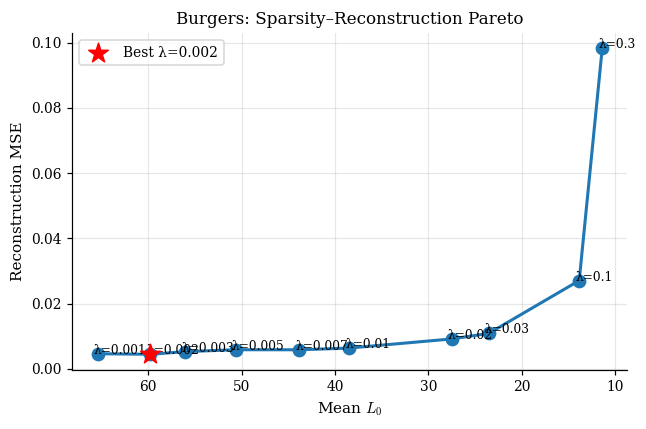

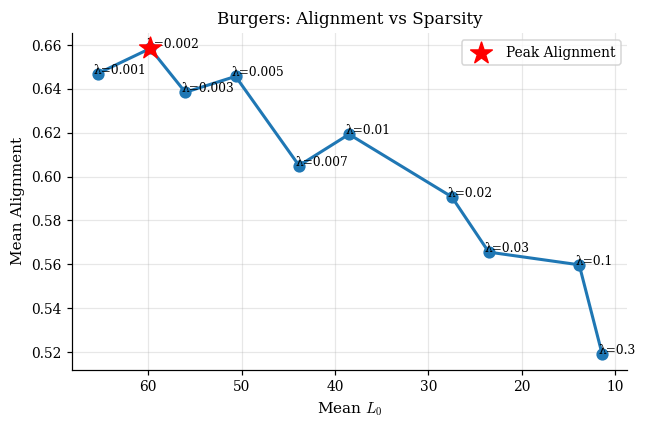

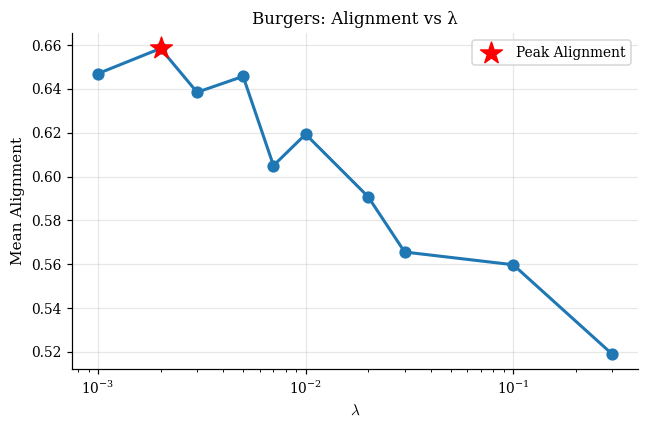

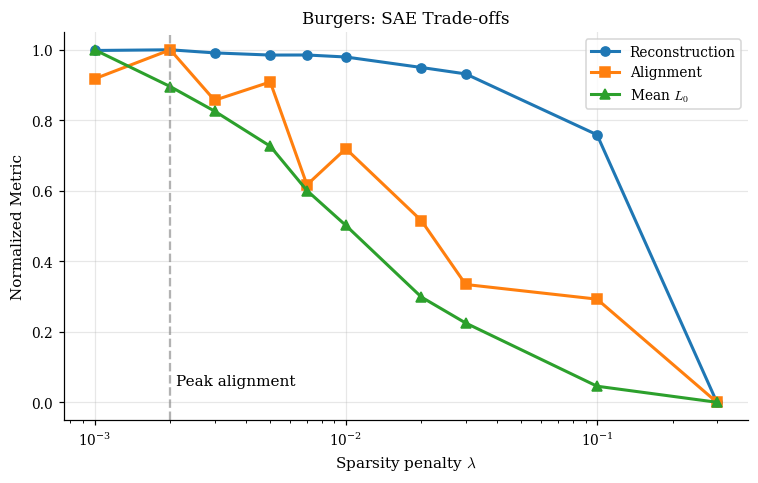

In [61]:
plot_pareto(results_df_b, "Burgers")

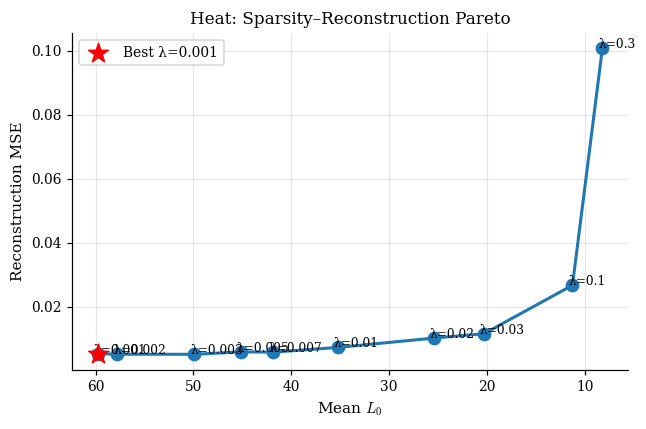

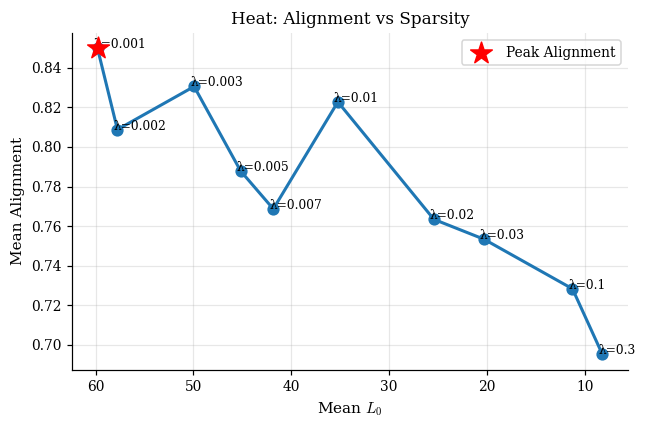

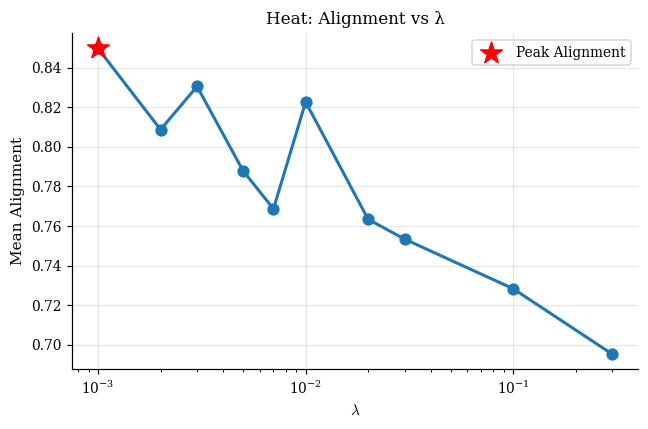

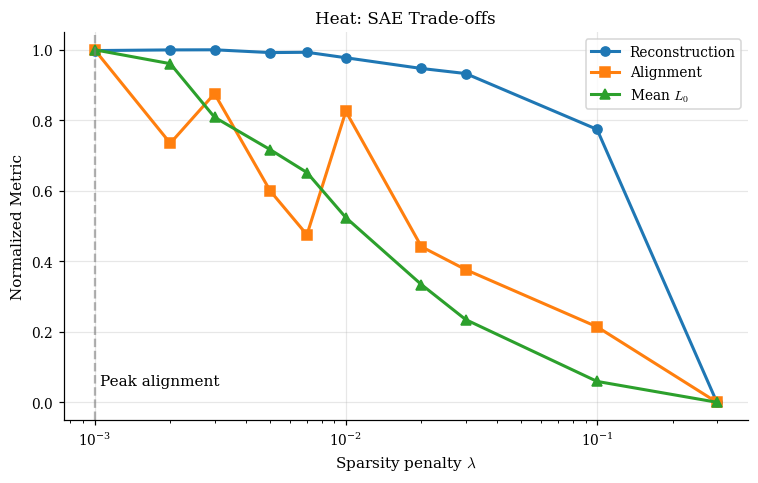

In [62]:
plot_pareto(results_df_h, "Heat")

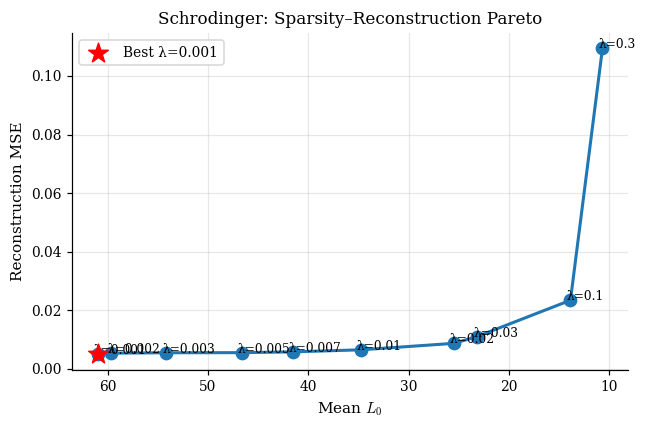

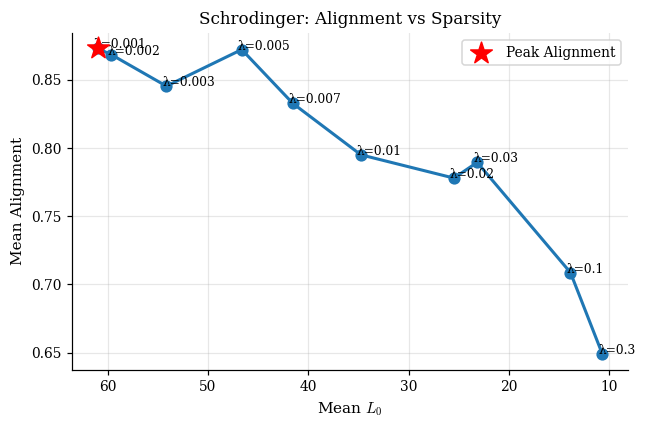

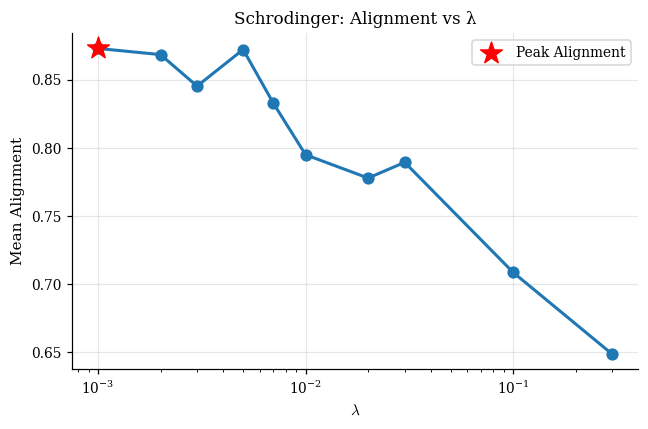

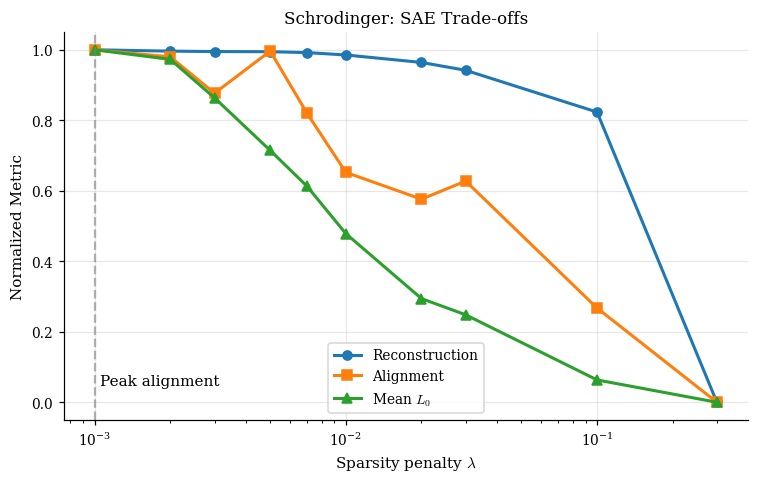

In [63]:
plot_pareto(results_df_s, "Schrodinger")